In [9]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd


In [10]:
#norm
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "legend.fontsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    
    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.top": False,
    "ytick.right": False,
    
    "axes.grid": True,
    "grid.color": "#7F8C8D",
    "grid.linestyle": ":", 
    "grid.alpha": 0.5,
    
    "legend.frameon": True,
    
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "savefig.bbox": "tight"
})

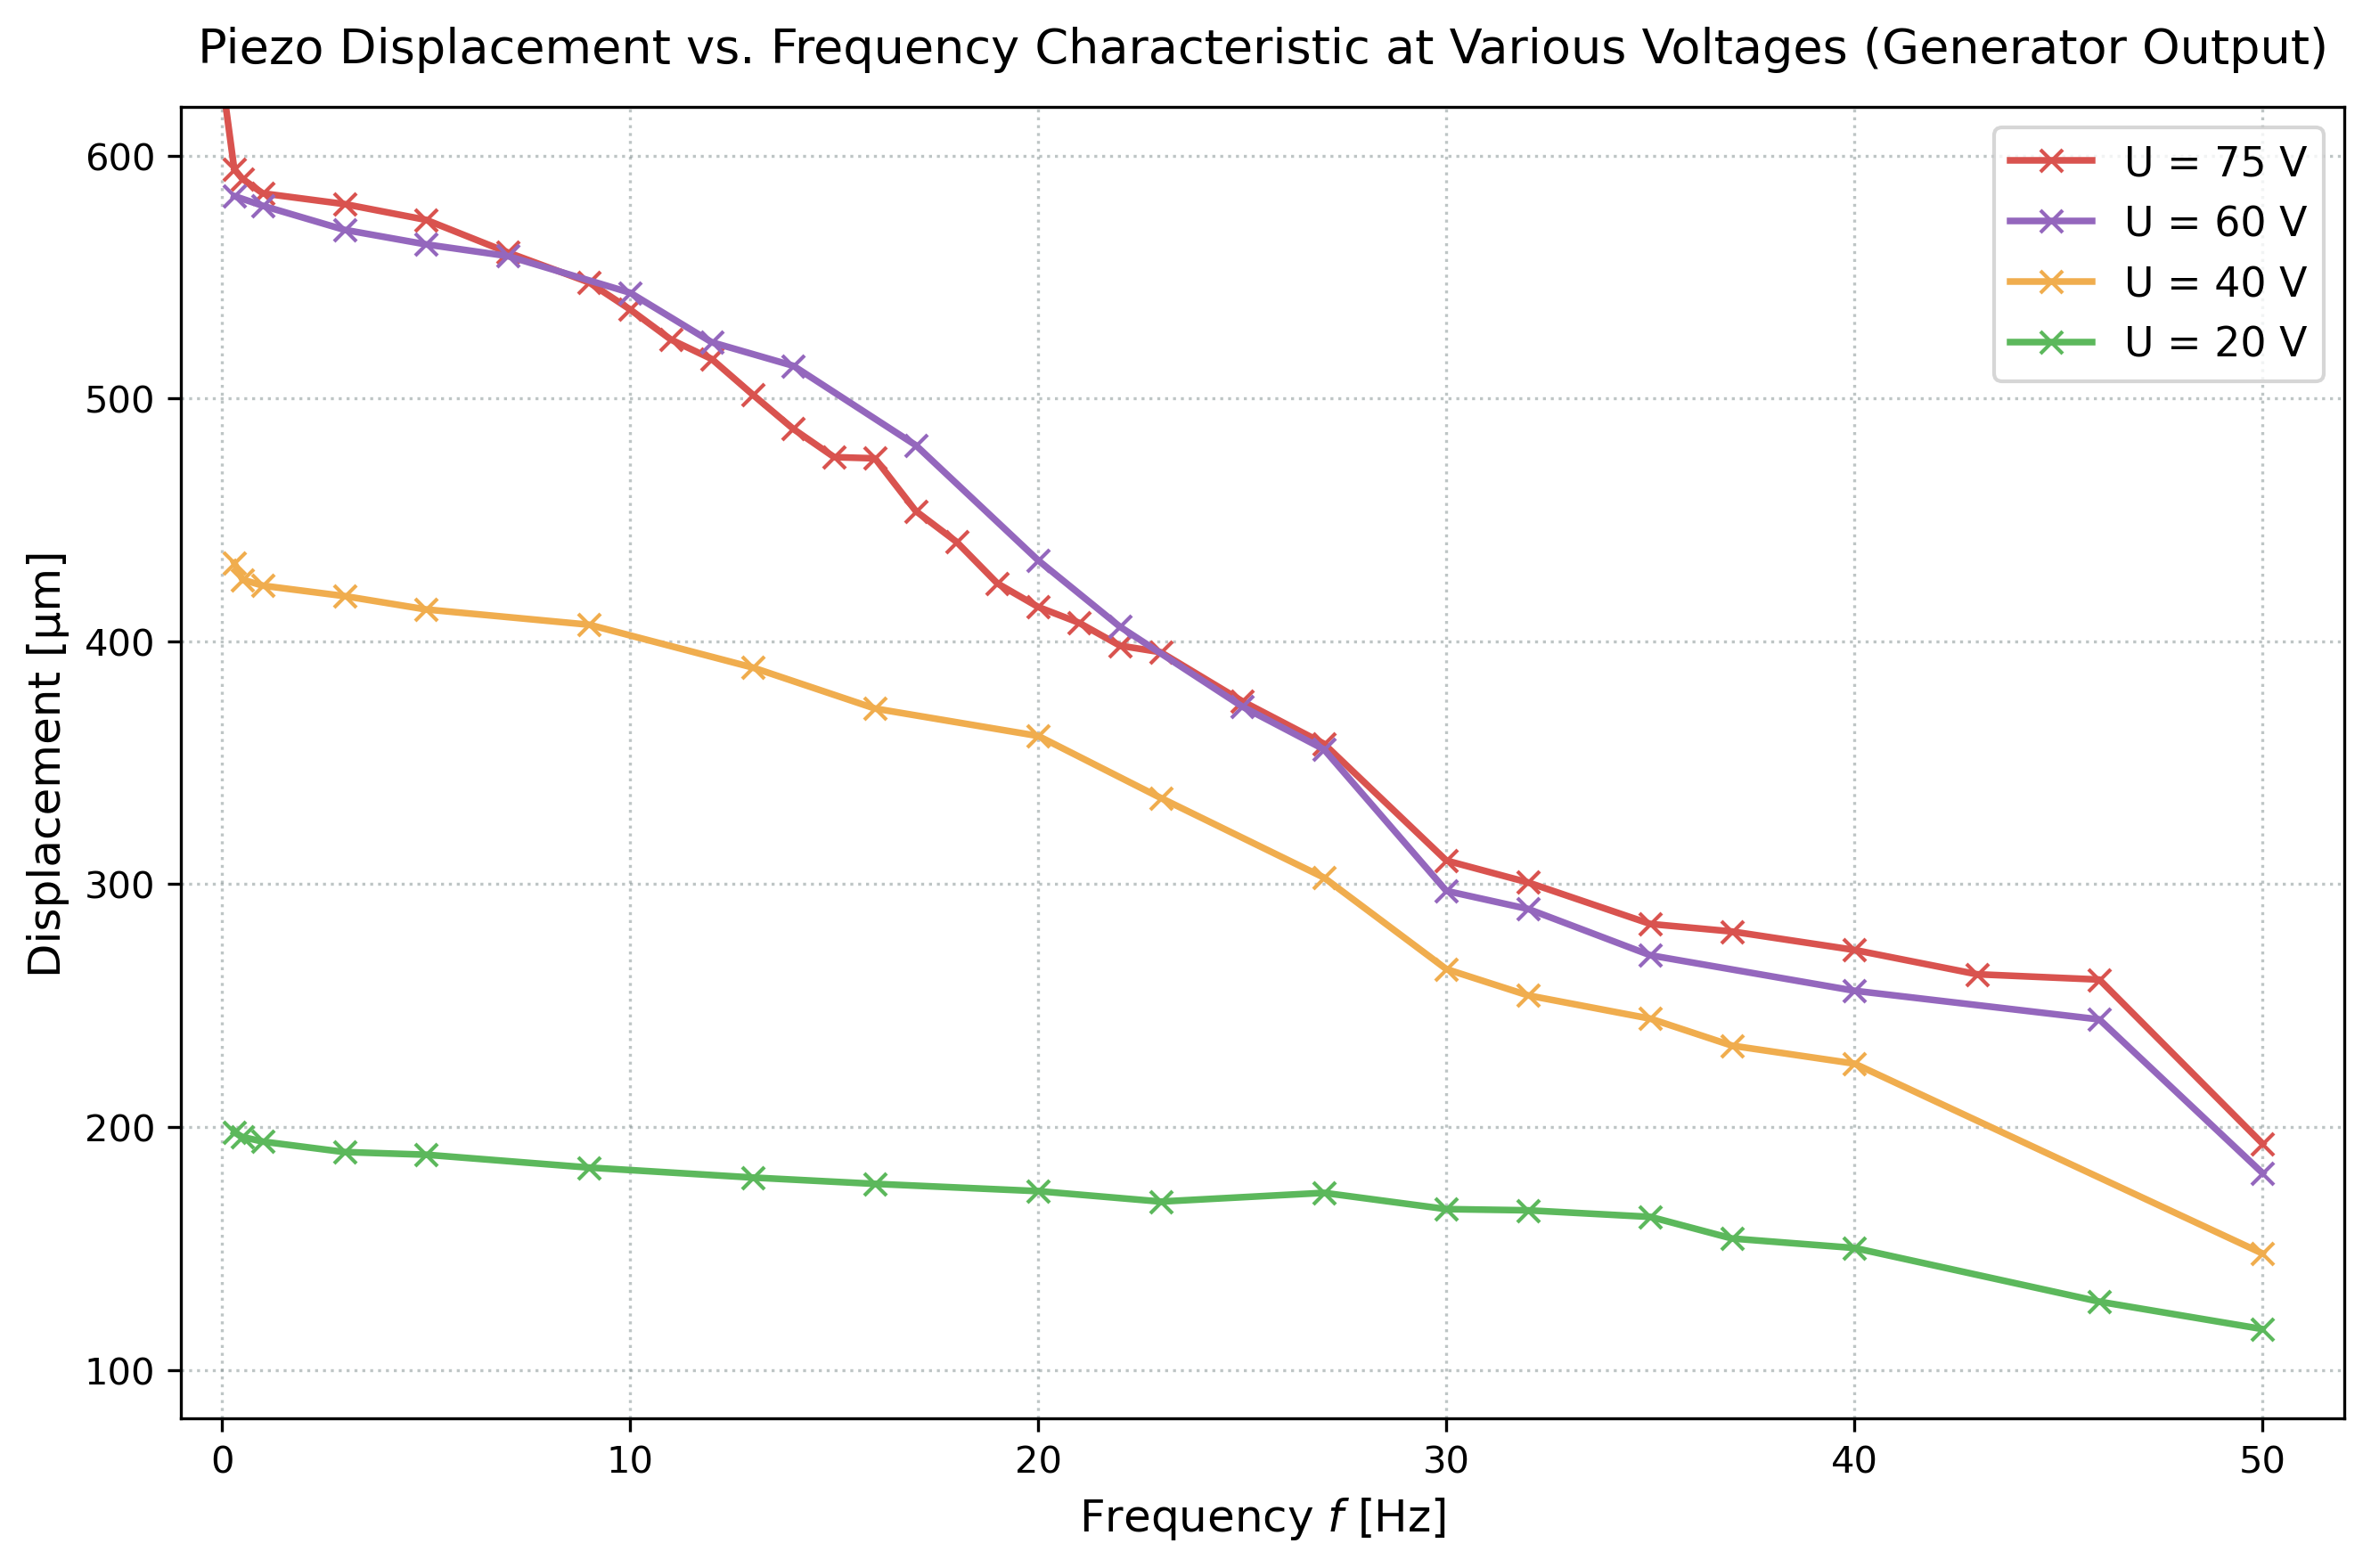

In [11]:
#ohne prototyp nur piezo

base_path = "/Users/trinity/Desktop/bachelor.thesis/measurements/"
file_path = base_path + "frequency_vs_displacement_piezo.csv"

df = pd.read_csv(file_path)

measurements = [
    {
        "name": "75 V",  #ntspricht U: 3.75 V
        "f_col": "f [Hz]",
        "u_col": "U:3.75V",
        "color": "#D9534F",
    },
    {
        "name": "60 V",  #entspricht U: 3 V
        "f_col": "f [Hz].1",
        "u_col": "U:3V",
        "color": "#9467BD",
    },
    {
        "name": "40 V",  #entspricht U: 2 V
        "f_col": "f [Hz].2",
        "u_col": "U:2V",
        "color": "#F0AD4E",
    },
    {
        "name": "20 V",  # entspricht U: 1 V
        "f_col": "f [Hz].3",
        "u_col": "U:1V",
        "color": "#5CB85C",
    },
]
plt.figure(figsize=(9, 6))

for m in measurements:
  #NaN-Werte entfernen weg nach Frequenz aufsteigend sortieren
  sub_df = df[[m["f_col"], m["u_col"]]].dropna().sort_values(by=m["f_col"])

  plt.plot(
      sub_df[m["f_col"]],
      sub_df[m["u_col"]],
      color=m["color"],
      linestyle="-",
      linewidth=1.8,
      marker="x",
      markersize=6,
      label=f"U = {m['name']}",
  )

plt.title(
    "Piezo Displacement vs. Frequency Characteristic at Various Voltages"
    " (Generator Output)",
    fontsize=13,
    pad=12,
)
plt.xlabel("Frequency $f$ [Hz]")
plt.ylabel("Displacement [µm]", fontsize=12)

plt.grid(True)


plt.xlim(left=-1, right=52)
plt.ylim(bottom=80, top=620)

plt.legend(loc="upper right")
plt.tight_layout()

#save_path = ("/Users/trinity/Desktop/bachelor.thesis/ba_plots/prototype/piezo/piezo_frequency_characteristic.pdf")
#plt.savefig(save_path, format="pdf")

plt.show() 


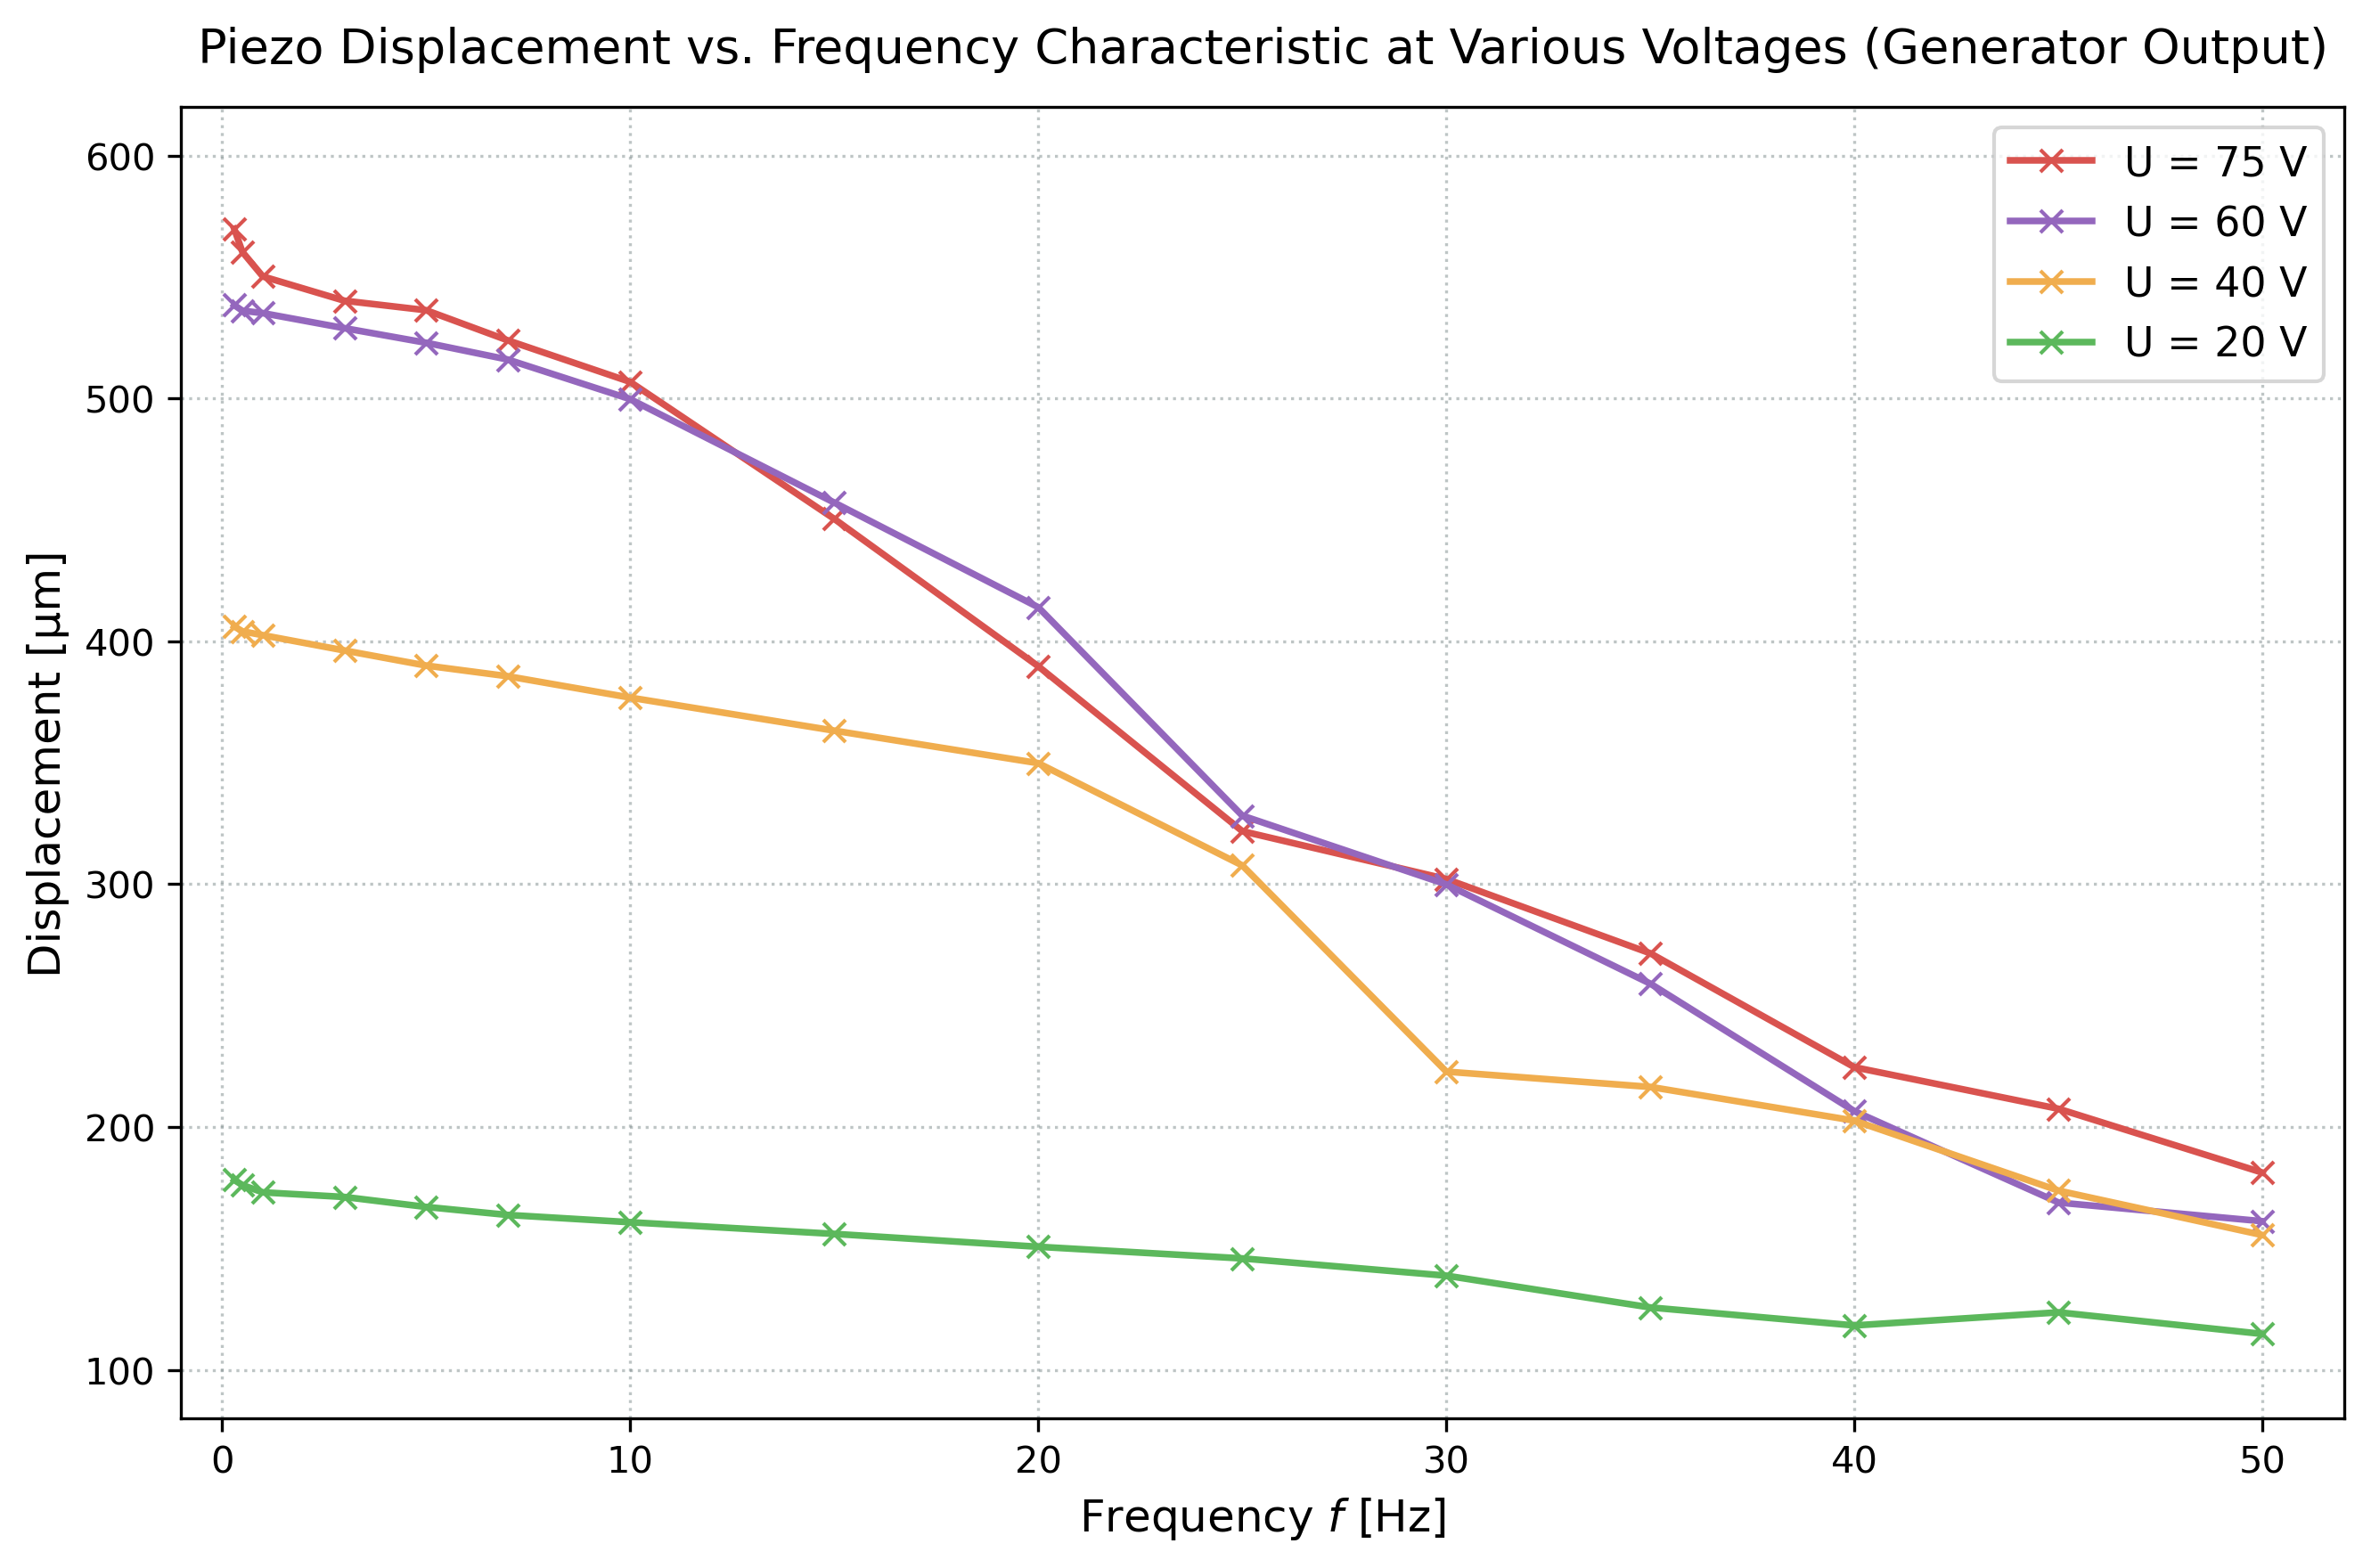

In [12]:
# Daten direkt mit numpy.genfromtxt einlesen
data = np.genfromtxt(
    "/Users/trinity/Desktop/bachelor.thesis/measurements/frequency_vs_displacement_prototype.csv",
    delimiter=",",
)
frequency = data[:, 0]
V75 = data[:, 1]
V60 = data[:, 2]
V40 = data[:, 3]
V20 = data[:, 4]

# Konfiguration der Linien und Farben entsprechend deinem Design
measurements = [
    {"name": "75 V", "data": V75, "color": "#D9534F"},
    {"name": "60 V", "data": V60, "color": "#9467BD"},
    {"name": "40 V", "data": V40, "color": "#F0AD4E"},
    {"name": "20 V", "data": V20, "color": "#5CB85C"},
]

plt.figure(figsize=(9, 6))

for m in measurements:
  plt.plot(
      frequency,
      m["data"],
      color=m["color"],
      linestyle="-",
      linewidth=1.8,
      marker="x",
      markersize=6,
      label=f"U = {m['name']}",
  )

plt.title(
    "Piezo Displacement vs. Frequency Characteristic at Various Voltages"
    " (Generator Output)",
    fontsize=13,
    pad=12,
)
plt.xlabel("Frequency $f$ [Hz]", fontsize=12)
plt.ylabel("Displacement [µm]", fontsize=12)

plt.grid(True)

plt.xlim(left=-1, right=52)
plt.ylim(bottom=80, top=620)

plt.legend(loc="upper right")
plt.tight_layout()

#save_path = "/Users/trinity/Desktop/bachelor.thesis/ba_plots/prototype/piezo/piezo_frequency_characteristic.pdf"
#plt.savefig(save_path, format="pdf")

plt.show()